# NLP Lab Programs — Sklearn Version
All representations (TF-IDF, BoW, N-grams, OHE) and models via sklearn

## Program 1 — Text Summarization using TF-IDF (sklearn)

In [1]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

STOPWORDS = set(stopwords.words('english'))

def sentence_tokenize(text):
    return nltk.sent_tokenize(text)

def preprocess(sentence):
    sentence = re.sub(r'[^\w\s]', '', sentence.lower())
    return ' '.join([w for w in nltk.word_tokenize(sentence) if w not in STOPWORDS])

def summarize(text, length):
    sentences = sentence_tokenize(text)
    processed = [preprocess(s) for s in sentences]

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(processed)

    scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
    score_dict = {sentences[i]: scores[i] for i in range(len(sentences))}

    ranked = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
    selected = [s[0] for s in ranked[:length]]
    summary = [s for s in sentences if s in selected]
    return ' '.join(summary), scores, sentences, processed, tfidf_matrix, vectorizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
text = input("Enter Paragraph:\n")
summary_length = int(input("Enter number of sentences for summary: "))


print("STEP 1: DATA ACQUISITION")

print("Original Text:")
print(text)

sentences = sentence_tokenize(text)
print(f"\nTotal Sentences: {len(sentences)}")


print("STEP 2: TEXT CLEANING")

processed = [preprocess(s) for s in sentences]
for i, (orig, proc) in enumerate(zip(sentences, processed), 1):
    print(f"Sentence {i} (original) : {orig}")
    print(f"Sentence {i} (cleaned)  : {proc}")


print("STEP 3: PREPROCESSING")

for i, proc in enumerate(processed, 1):
    print(f"Sentence {i} tokens: {nltk.word_tokenize(proc)}")


print("STEP 4: FEATURE ENGINEERING (TF-IDF via sklearn)")

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed)
print(f"Vocabulary Size  : {len(vectorizer.vocabulary_)}")
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
for i, (s, score) in enumerate(zip(sentences, scores), 1):
    print(f"Sentence {i} Score = {score:.4f}")


print("STEP 5: MODELING OUTPUT (Summary)")

score_dict = {sentences[i]: scores[i] for i in range(len(sentences))}
ranked = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
selected = [s[0] for s in ranked[:summary_length]]
summary = ' '.join([s for s in sentences if s in selected])
print(summary)


Enter Paragraph:
Born in Ranchi, Dhoni made his first class debut for Bihar in 1999. He made his debut for the Indian cricket team on 23 December 2004 in an ODI against Bangladesh and played his first test a year later against Sri Lanka. In 2007, he became the captain of the ODI side before taking over in all formats by 2008. Dhoni retired from test cricket in 2014, but continued playing in limited overs cricket till 2019. He has scored 17,266 runs in international cricket including 10,000 plus runs at an average of more than 50 in ODIs.
Enter number of sentences for summary: 2

STEP 1: DATA ACQUISITION
Original Text:
Born in Ranchi, Dhoni made his first class debut for Bihar in 1999. He made his debut for the Indian cricket team on 23 December 2004 in an ODI against Bangladesh and played his first test a year later against Sri Lanka. In 2007, he became the captain of the ODI side before taking over in all formats by 2008. Dhoni retired from test cricket in 2014, but continued playing 

## Program 2 — Word Cloud using TF-IDF (sklearn)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



STEP 1: DATA ACQUISITION
Input Text:
On 14 November 1987, at age 14, Tendulkar was selected to represent Bombay in the Ranji Trophy for the 1987-88 season, but he was not selected for the final eleven in any of the matches, though he was ...

STEP 2: TEXT CLEANING
Cleaned Text:
november 1987 age tendulkar selected represent bombay ranji trophy 198788 season selected final eleven matches though often used substitute fielder43 year later december 1988 aged years 232 days tendu ...

STEP 3: PREPROCESSING
Total Tokens: 83
Sample Tokens: ['november', '1987', 'age', 'tendulkar', 'selected', 'represent', 'bombay', 'ranji', 'trophy', '198788', 'season', 'selected', 'final', 'eleven', 'matches']

STEP 4: FEATURE ENGINEERING (TF-IDF via sklearn)
Unique Words: 67
Top 10 words by TF-IDF score:
  bombay: 0.2683
  play: 0.2683
  selected: 0.2683
  team: 0.2683
  tendulkar: 0.2683
  century: 0.1789
  cricket: 0.1789
  debut: 0.1789
  indian: 0.1789
  trophy: 0.1789

STEP 5: MODELING OUTPUT (Word Clo

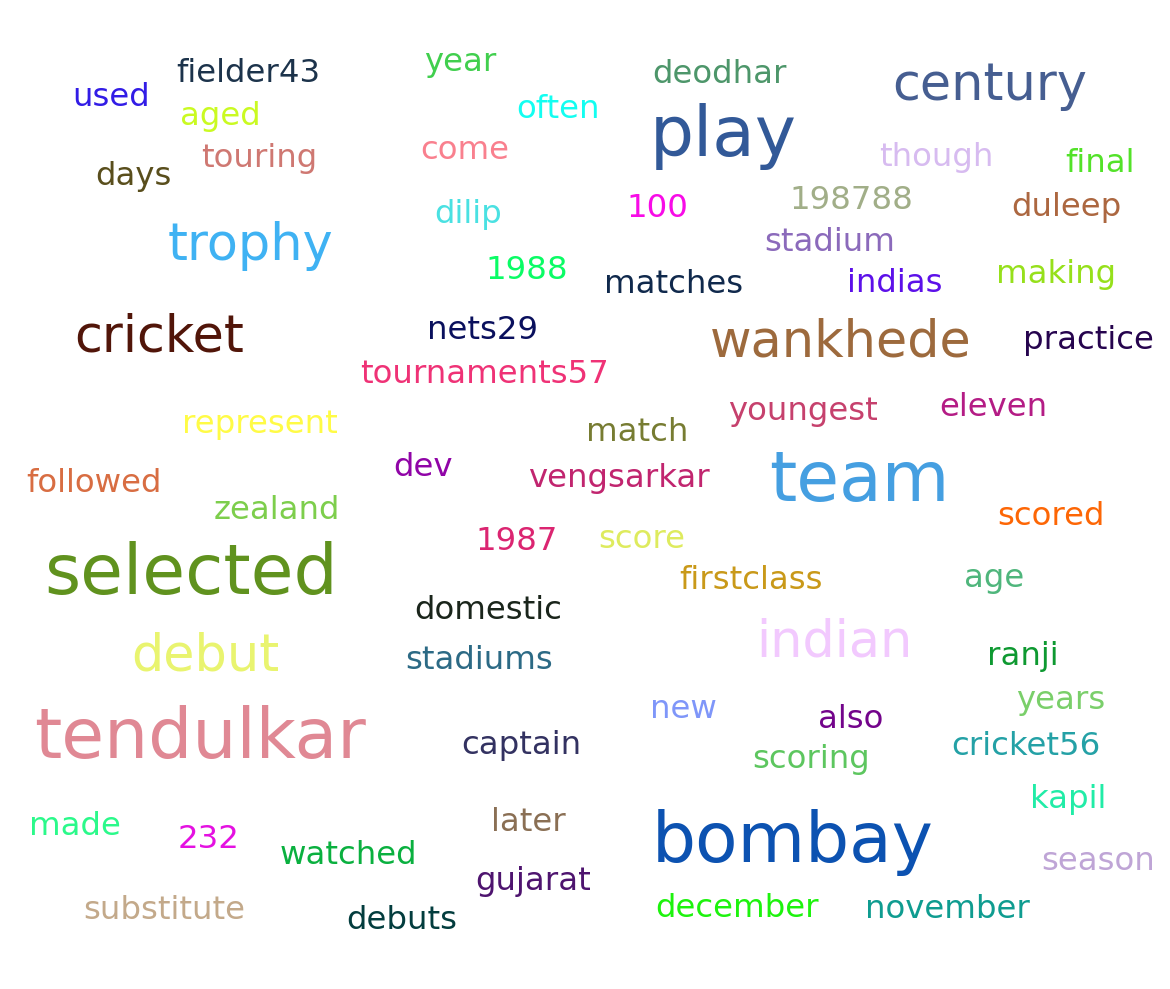

In [5]:
import re
import random
import numpy as np
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

def preprocess(text):
    text = re.sub(r'[^\w\s]', '', text.lower())
    return ' '.join([w for w in nltk.word_tokenize(text) if w not in set(stopwords.words('english')) and len(w) > 2])

def get_tfidf_freq(text):
    processed = preprocess(text)
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([processed])
    vocab = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.toarray()[0]
    return {vocab[i]: scores[i] for i in range(len(vocab)) if scores[i] > 0}

def wordcloud(freq):
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    freq_sorted = sorted(freq.items(), key=lambda x: x[1], reverse=True)
    if not freq_sorted:
        plt.show()
        return
    max_freq = freq_sorted[0][1]
    placed_boxes = []
    for word, count in freq_sorted:
        font_size = 10 + (count / max_freq) * 40
        placed = False
        for _ in range(5000):
            x = random.uniform(0.05, 0.95)
            y = random.uniform(0.05, 0.95)
            txt = ax.text(x, y, word, fontsize=font_size, ha='center', va='center', color=(random.random(), random.random(), random.random()))
            fig.canvas.draw()
            bbox = txt.get_window_extent(renderer=fig.canvas.get_renderer())
            overlap = False
            for existing in placed_boxes:
                if bbox.overlaps(existing):
                    overlap = True
                    break
            if not overlap:
                placed_boxes.append(bbox)
                placed = True
                break
            txt.remove()
        if not placed:
            txt.remove()
    plt.tight_layout()
    plt.show()

text = """On 14 November 1987, at age 14, Tendulkar was selected to represent Bombay in the Ranji Trophy for the 1987-88 season, but he was not selected for the final eleven in any of the matches, though he was often used as a substitute fielder.[43] A year later, on 11 December 1988, aged 15 years and 232 days, Tendulkar made his debut for Bombay against Gujarat at Wankhede Stadium and scored 100 (not out) in that match, making him the youngest Indian to score a century on debut in first-class cricket.[56] He was selected to play for the team by Bombay captain Dilip Vengsarkar, who watched him play Kapil Dev in Wankhede Stadium's cricket practice nets,[29] where the Indian team had come to play against the touring New Zealand team. Tendulkar followed this by scoring a century each in his Deodhar and Duleep Trophy debuts, which are also India's domestic cricket tournaments.[57]"""


print("STEP 1: DATA ACQUISITION")

print("Input Text:")
print(text[:200], "...")


print("STEP 2: TEXT CLEANING")

cleaned = preprocess(text)
print("Cleaned Text:")
print(cleaned[:200], "...")


print("STEP 3: PREPROCESSING")

tokens = nltk.word_tokenize(cleaned)
print(f"Total Tokens: {len(tokens)}")
print(f"Sample Tokens: {tokens[:15]}")


print("STEP 4: FEATURE ENGINEERING (TF-IDF via sklearn)")

freq = get_tfidf_freq(text)
print(f"Unique Words: {len(freq)}")
print("Top 10 words by TF-IDF score:")
for word, score in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {word}: {score:.4f}")


print("STEP 5: MODELING OUTPUT (Word Cloud)")

wordcloud(freq)


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 6.33.5 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.6 which is incompatible.
pandas 2.1.4 requires numpy<2,>=1.23.2; python_version == "3.11", but you have numpy 2.4.6 which is incompatible.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.6 which is incompatible.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.4.6 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------- ----------------------------- 3.4/12.6 MB 28.9 MB/s eta 0:00:01
   -------------- ------------------------- 4.7/12.6 MB 11.0 MB/s eta 0:00:01
   ------------------ --------------------- 5.8/12.6 MB 9.5 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.6 MB 8.1 MB/s eta 0:00:01
   ------------------------ --------------- 7.9/12.6 MB 7.5 MB/s eta 0:00:01
   --------------------------- ------------ 8.7/12.6 MB 6.8 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.6 MB 6.4 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.6 MB 5.8 MB/s eta 0:00:01
   ------------------------------ --------- 9.7/12.6 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 10.2/12.6 MB 4.8 MB/s eta 0:00:01
   ---------------------------------- ----- 10.7/12.6 MB 4.7 MB/s eta 0:00:01
   ------------------------------------ --- 11.5/12.6 MB 4.5 MB/s eta 0:00:01
 

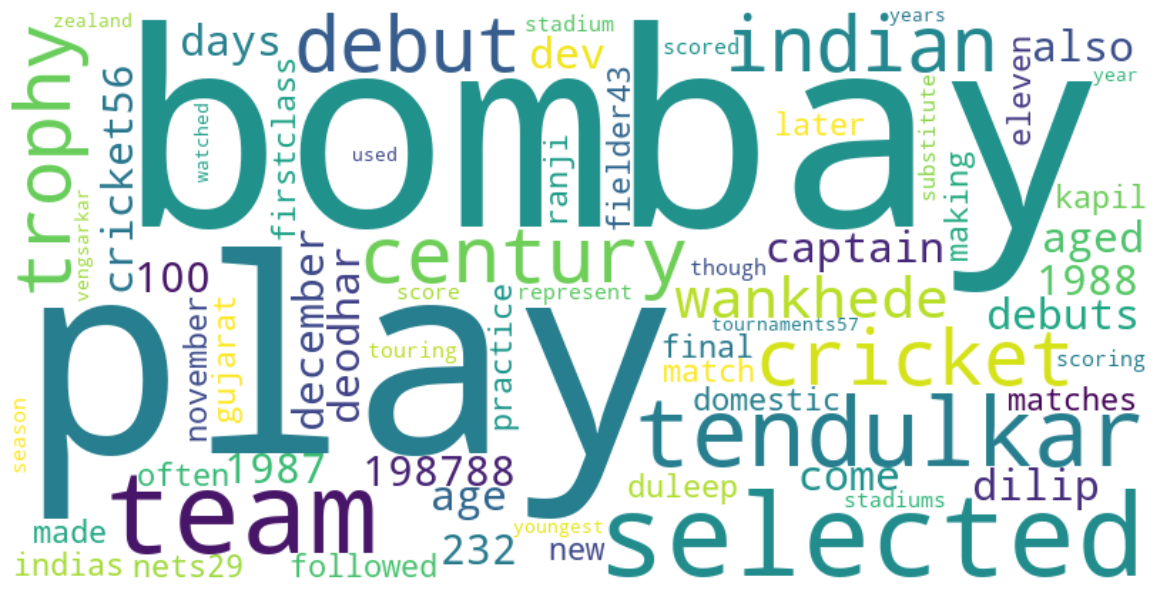

In [17]:
!pip install wordcloud
import re
import numpy as np
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

def preprocess(text):
    text = re.sub(r'[^\w\s]', '', text.lower())
    return ' '.join([w for w in nltk.word_tokenize(text) if w not in set(stopwords.words('english')) and len(w) > 2])

def get_tfidf_freq(text):
    processed = preprocess(text)
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([processed])
    vocab = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.toarray()[0]
    return {vocab[i]: scores[i] for i in range(len(vocab)) if scores[i] > 0}

def wordcloud(freq):
    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(freq)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

text = """On 14 November 1987, at age 14, Tendulkar was selected to represent Bombay in the Ranji Trophy for the 1987-88 season, but he was not selected for the final eleven in any of the matches, though he was often used as a substitute fielder.[43] A year later, on 11 December 1988, aged 15 years and 232 days, Tendulkar made his debut for Bombay against Gujarat at Wankhede Stadium and scored 100 (not out) in that match, making him the youngest Indian to score a century on debut in first-class cricket.[56] He was selected to play for the team by Bombay captain Dilip Vengsarkar, who watched him play Kapil Dev in Wankhede Stadium's cricket practice nets,[29] where the Indian team had come to play against the touring New Zealand team. Tendulkar followed this by scoring a century each in his Deodhar and Duleep Trophy debuts, which are also India's domestic cricket tournaments.[57]"""


print("STEP 1: DATA ACQUISITION")
print("Input Text:")
print(text[:200], "...")

print("\nSTEP 2: TEXT CLEANING")
cleaned = preprocess(text)
print("Cleaned Text:")
print(cleaned[:200], "...")

print("\nSTEP 3: PREPROCESSING")
tokens = nltk.word_tokenize(cleaned)
print(f"Total Tokens: {len(tokens)}")
print(f"Sample Tokens: {tokens[:15]}")

print("\nSTEP 4: FEATURE ENGINEERING (TF-IDF via sklearn)")
freq = get_tfidf_freq(text)
print(f"Unique Words: {len(freq)}")
print("Top 10 words by TF-IDF score:")
for word, score in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {word}: {score:.4f}")

print("\nSTEP 5: MODELING OUTPUT (Word Cloud)")
wordcloud(freq)

## Program 3 — Sentiment Analysis using TF-IDF + Logistic Regression (sklearn)

In [ ]:
import re
import pandas as pd
import numpy as np
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


print("STEP 1: DATA ACQUISITION")

df = pd.read_csv(r"C:\Users\ig134\Downloads\Musical_instruments_reviews 4.csv")
df = df[["summary", "overall"]]
df.dropna(inplace=True)
print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())


print("STEP 2: TEXT CLEANING")

def label_sentiment(rating):
    if rating == 5: return 1
    elif rating >= 3: return 0
    else: return -1

df["label"] = df["overall"].apply(label_sentiment)
min_count = df["label"].value_counts().min()
df_balanced = pd.concat([df[df["label"] == 1].sample(min_count, random_state=42), df[df["label"] == 0].sample(min_count, random_state=42), df[df["label"] == -1].sample(min_count, random_state=42)])
df = df_balanced.sample(frac=1, random_state=42)

stop_words = set(stopwords.words("english"))
def clean(text):
    text = re.sub(r'[^\w\s]', '', str(text).lower())
    return ' '.join([w for w in nltk.word_tokenize(text) if w not in stop_words])

df["cleaned"] = df["summary"].apply(clean)
print("Before:", df["summary"].iloc[0])
print("After :", df["cleaned"].iloc[0])
print("\nClass Distribution:")
print(df["label"].value_counts())


print("STEP 3: PREPROCESSING")

print("Sample cleaned tokens:")
for i in range(3):
    print(f"  Doc {i+1}: {nltk.word_tokenize(df['cleaned'].iloc[i])[:8]}")


print("STEP 4: FEATURE ENGINEERING (TF-IDF via sklearn)")

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["cleaned"])
y = df["label"].values
print(f"Vocabulary Size  : {len(vectorizer.vocabulary_)}")
print(f"TF-IDF Matrix Shape: {X.shape}")
print(f"Sample vocab     : {list(vectorizer.vocabulary_.keys())[:10]}")


print("STEP 5: MODELING")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Sample predictions (first 5):")
for i in range(5):
    print(f"  Actual: {y_test[i]}  |  Predicted: {y_pred[i]}")


print("STEP 6: EVALUATION")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

def predict_text(text):
    cleaned = clean(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    if pred == 1: print("Positive Review")
    elif pred == 0: print("Neutral Review")
    else: print("Negative Review")

while True:
    review = input("\nEnter Review (or type exit): ")
    if review.lower() == "exit":
        break
    predict_text(review)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


STEP 1: DATA ACQUISITION
Dataset Shape: (10261, 2)

First 5 Records:
                                 summary  overall
0                                   good      5.0
1                                   Jake      5.0
2                   It Does The Job Well      5.0
3          GOOD WINDSCREEN FOR THE MONEY      5.0
4  No more pops when I record my vocals.      5.0
STEP 2: TEXT CLEANING
Before: Belief is the key.
After : belief key

Class Distribution:
label
-1    467
 1    467
 0    467
Name: count, dtype: int64
STEP 3: PREPROCESSING
Sample cleaned tokens:
  Doc 1: ['belief', 'key']
  Doc 2: ['bright']
  Doc 3: ['easy', 'handle']
STEP 4: FEATURE ENGINEERING (TF-IDF via sklearn)
Vocabulary Size  : 1499
TF-IDF Matrix Shape: (1401, 1499)
Sample vocab     : ['belief', 'key', 'bright', 'easy', 'handle', 'ok', 'nice', 'little', 'pick', 'holder']
STEP 5: MODELING
Train size: 1120  |  Test size: 281
Sample predictions (first 5):
  Actual: 0  |  Predicted: 0
  Actual: -1  |  Predicted: -1
  A

## Program 4 — Sentiment Analysis using N-grams + Logistic Regression (sklearn)

In [ ]:
import re
import pandas as pd
import numpy as np
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split



print("STEP 1: DATA ACQUISITION")

df = pd.read_csv(r"C:\Users\ig134\Downloads\Musical_instruments_reviews 4.csv")
df = df[["summary", "overall"]]
df.dropna(inplace=True)
print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())


print("STEP 2: TEXT CLEANING")

def label_sentiment(rating):
    if rating == 5: return 1
    elif rating >= 3: return 0
    else: return -1

df["label"] = df["overall"].apply(label_sentiment)
min_count = df["label"].value_counts().min()
df_balanced = pd.concat([df[df["label"] == 1].sample(min_count, random_state=42), df[df["label"] == 0].sample(min_count, random_state=42), df[df["label"] == -1].sample(min_count, random_state=42)])
df = df_balanced.sample(frac=1, random_state=42)

stop_words = set(stopwords.words("english"))
def clean(text):
    text = re.sub(r'[^\w\s]', '', str(text).lower())
    return ' '.join([w for w in nltk.word_tokenize(text) if w not in stop_words])

df["cleaned"] = df["summary"].apply(clean)
print("Before:", df["summary"].iloc[0])
print("After :", df["cleaned"].iloc[0])
print("\nClass Distribution:")
print(df["label"].value_counts())


print("STEP 3: PREPROCESSING")

print("Sample cleaned tokens:")
for i in range(3):
    print(f"  Doc {i+1}: {nltk.word_tokenize(df['cleaned'].iloc[i])[:8]}")


print("STEP 4: FEATURE ENGINEERING (N-grams via sklearn)")

vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X = vectorizer.fit_transform(df["cleaned"])
y = df["label"].values
print(f"N-gram range     : (1, 2)")
print(f"Vocabulary Size  : {len(vectorizer.vocabulary_)}")
print(f"Feature Matrix Shape: {X.shape}")
print(f"Sample N-grams   : {list(vectorizer.vocabulary_.keys())[:10]}")


print("STEP 5: MODELING")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Sample predictions (first 5):")
for i in range(5):
    print(f"  Actual: {y_test[i]}  |  Predicted: {y_pred[i]}")


print("STEP 6: EVALUATION")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

def predict_text(text):
    cleaned = clean(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    if pred == 1: print("Positive")
    elif pred == 0: print("Neutral")
    else: print("Negative")

predict_text("The food was amazing and staff was friendly")
predict_text("Food was okay, nothing special")
predict_text("Bad service and bad food")
predict_text("Bad bad bad bad")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


STEP 1: DATA ACQUISITION
Dataset Shape: (10261, 2)

First 5 Records:
                                 summary  overall
0                                   good      5.0
1                                   Jake      5.0
2                   It Does The Job Well      5.0
3          GOOD WINDSCREEN FOR THE MONEY      5.0
4  No more pops when I record my vocals.      5.0
STEP 2: TEXT CLEANING
Before: Belief is the key.
After : belief key

Class Distribution:
label
-1    467
 1    467
 0    467
Name: count, dtype: int64
STEP 3: PREPROCESSING
Sample cleaned tokens:
  Doc 1: ['belief', 'key']
  Doc 2: ['bright']
  Doc 3: ['easy', 'handle']
STEP 4: FEATURE ENGINEERING (N-grams via sklearn)
N-gram range     : (1, 2)
Vocabulary Size  : 3952
Feature Matrix Shape: (1401, 3952)
Sample N-grams   : ['belief', 'key', 'belief key', 'bright', 'easy', 'handle', 'easy handle', 'ok', 'nice', 'little']
STEP 5: MODELING
Train size: 1120  |  Test size: 281
Sample predictions (first 5):
  Actual: 0  |  Predicte

## Program 5 — Sentiment Analysis using Bag of Words + Naive Bayes (sklearn)

In [ ]:
import re
import pandas as pd
import numpy as np
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


print("STEP 1: DATA ACQUISITION")

df = pd.read_csv(r"C:\Users\ig134\Downloads\Musical_instruments_reviews 4.csv")
df = df[["summary", "overall"]]
df.dropna(inplace=True)
print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())


print("STEP 2: TEXT CLEANING")

def label_sentiment(rating):
    if rating == 5: return 1
    elif rating >= 3: return 0
    else: return -1

df["label"] = df["overall"].apply(label_sentiment)
min_count = df["label"].value_counts().min()
df_balanced = pd.concat([df[df["label"] == 1].sample(min_count, random_state=42), df[df["label"] == 0].sample(min_count, random_state=42), df[df["label"] == -1].sample(min_count, random_state=42)])
df = df_balanced.sample(frac=1, random_state=42)

stop_words = set(stopwords.words("english"))
def clean(text):
    text = re.sub(r'[^\w\s]', '', str(text).lower())
    return ' '.join([w for w in nltk.word_tokenize(text) if w not in stop_words])

df["cleaned"] = df["summary"].apply(clean)
print("Before:", df["summary"].iloc[0])
print("After :", df["cleaned"].iloc[0])
print("\nClass Distribution:")
print(df["label"].value_counts())


print("STEP 3: PREPROCESSING")

print("Sample cleaned tokens:")
for i in range(3):
    print(f"  Doc {i+1}: {nltk.word_tokenize(df['cleaned'].iloc[i])[:8]}")


print("STEP 4: FEATURE ENGINEERING (Bag of Words via sklearn)")

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["cleaned"])
y = df["label"].values
print(f"Vocabulary Size    : {len(vectorizer.vocabulary_)}")
print(f"BoW Matrix Shape   : {X.shape}")
print(f"Sample vocab       : {list(vectorizer.vocabulary_.keys())[:10]}")
print(f"Sample BoW vector  : {X[0].toarray()[0][:10]}")


print("STEP 5: MODELING")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Sample predictions (first 5):")
for i in range(5):
    print(f"  Actual: {y_test[i]}  |  Predicted: {y_pred[i]}")


print("STEP 6: EVALUATION")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

def predict_text(text):
    cleaned = clean(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    if pred == 1: print("Positive Review")
    elif pred == 0: print("Neutral Review")
    else: print("Negative Review")

while True:
    review = input("\nEnter Review (or type exit): ")
    if review.lower() == "exit":
        break
    predict_text(review)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


STEP 1: DATA ACQUISITION
Dataset Shape: (10261, 2)

First 5 Records:
                                 summary  overall
0                                   good      5.0
1                                   Jake      5.0
2                   It Does The Job Well      5.0
3          GOOD WINDSCREEN FOR THE MONEY      5.0
4  No more pops when I record my vocals.      5.0
STEP 2: TEXT CLEANING
Before: Belief is the key.
After : belief key

Class Distribution:
label
-1    467
 1    467
 0    467
Name: count, dtype: int64
STEP 3: PREPROCESSING
Sample cleaned tokens:
  Doc 1: ['belief', 'key']
  Doc 2: ['bright']
  Doc 3: ['easy', 'handle']
STEP 4: FEATURE ENGINEERING (Bag of Words via sklearn)
Vocabulary Size    : 1499
BoW Matrix Shape   : (1401, 1499)
Sample vocab       : ['belief', 'key', 'bright', 'easy', 'handle', 'ok', 'nice', 'little', 'pick', 'holder']
Sample BoW vector  : [0 0 0 0 0 0 0 0 0 0]
STEP 5: MODELING
Train size: 1120  |  Test size: 281
Sample predictions (first 5):
  Actual: 

## Program 6 — Email Spam Detection using OHE + Random Forest (sklearn)

In [ ]:
import re
import random
import pandas as pd
import numpy as np
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


print("STEP 1: DATA ACQUISITION")

df = pd.read_csv(r"C:\Users\ig134\Downloads\spam.csv", encoding="latin-1")
df = df[["v1", "v2"]]
df.columns = ["label", "message"]
print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())
print("\nLabel Distribution:")
print(df["label"].value_counts())

print("\nSTEP 2: TEXT CLEANING")

df["label_enc"] = df["label"].apply(lambda x: 1 if x == "spam" else 0)

stop_words = set(stopwords.words("english"))

def clean(text):
    text = re.sub(r'[^\w\s]', '', str(text).lower())
    return ' '.join([w for w in nltk.word_tokenize(text) if w not in stop_words])

df["cleaned"] = df["message"].apply(clean)
print("Before:", df["message"].iloc[0])
print("After :", df["cleaned"].iloc[0])

print("\nSTEP 3: PREPROCESSING")

print("Sample cleaned tokens:")
for i in range(3):
    print(f"  Doc {i+1}: {nltk.word_tokenize(df['cleaned'].iloc[i])[:8]}")

print("\nSTEP 4: FEATURE ENGINEERING (One Hot Encoding via sklearn)")

vectorizer = CountVectorizer(binary=True)
X = vectorizer.fit_transform(df["cleaned"])
y = df["label_enc"].values
print(f"Vocabulary Size    : {len(vectorizer.vocabulary_)}")
print(f"OHE Matrix Shape   : {X.shape}")
print(f"Sample vocab       : {list(vectorizer.vocabulary_.keys())[:10]}")
print(f"Sample OHE vector  : {X[0].toarray()[0][:10]}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train — Ham: {(y_train==0).sum()}  Spam: {(y_train==1).sum()}")

def oversample_minority(X, y, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    X       = X.toarray()
    n0      = int((y == 0).sum())
    n1      = int((y == 1).sum())
    if n1 >= n0:
        return X, y
    needed  = n0 - n1
    src_idx = np.where(y == 1)[0]
    chosen  = np.random.choice(src_idx, needed, replace=True)
    X_extra = X[chosen].copy()
    drop    = np.random.random(X_extra.shape) < 0.05
    X_extra[drop] = 0.0
    X_new   = np.vstack([X, X_extra])
    y_new   = np.concatenate([y, np.ones(needed, dtype=y.dtype)])
    shuf    = np.random.permutation(len(y_new))
    return X_new[shuf], y_new[shuf]

X_bal, y_bal = oversample_minority(X_train, y_train)
print(f"Before — Ham: {(y_train==0).sum()}  Spam: {(y_train==1).sum()}")
print(f"After  — Ham: {(y_bal==0).sum()}  Spam: {(y_bal==1).sum()}")

print("\nSTEP 5: MODELING")

X_test_dense = X_test.toarray()

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    max_features='sqrt',
    class_weight='balanced',   # penalises missing spam more heavily
    random_state=42
)
model.fit(X_bal, y_bal)

# Lower vote threshold — predict spam if ≥40% of trees say spam
proba   = model.predict_proba(X_test_dense)[:, 1]
y_pred  = (proba >= 0.40).astype(int)

print("Sample predictions (first 5):")
for i in range(5):
    label_map = {0: "Not Spam", 1: "Spam"}
    print(f"  Actual: {label_map[y_test[i]]}  |  Predicted: {label_map[y_pred[i]]}")

print("\nSTEP 6: EVALUATION")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


def predict_message(text):
    cleaned = clean(text)
    vec     = vectorizer.transform([cleaned]).toarray()
    proba   = model.predict_proba(vec)[0][1]
    pred    = 1 if proba >= 0.40 else 0
    if pred == 1: print("Spam")
    else:         print("Not Spam")

while True:
    text = input("\nEnter the message: ")
    if text.lower() == "exit":
        break
    predict_message(text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


STEP 1: DATA ACQUISITION
Dataset Shape: (5572, 2)

First 5 Records:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

STEP 2: TEXT CLEANING
Before: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
After : go jurong point crazy available bugis n great world la e buffet cine got amore wat

STEP 3: PREPROCESSING
Sample cleaned tokens:
  Doc 1: ['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great']
  Doc 2: ['ok', 'lar', 'joking', 'wif', 'u', 'oni']
  Doc 3: ['free', 'entry', '2', 'wkly', 'comp', 'win', 'fa', 'cup']

STEP 4: FEATURE EN

## Program 7 — Topic Modelling using LDA (sklearn)

In [10]:
!pip install PyPDF2
!pip install python-docx

import os, re
import numpy as np
import nltk
from PyPDF2 import PdfReader
from docx import Document
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords')
nltk.download('punkt_tab')
STOP_WORDS = set(stopwords.words('english'))


def read_file(path):
    if path.endswith(".pdf"):
        text = ""
        reader = PdfReader(path)
        for page in reader.pages:
            content = page.extract_text()
            if content:
                text += content + " "
        return text
    elif path.endswith(".txt"):
        with open(path, "r", encoding="utf-8") as f:
            return f.read()
    elif path.endswith(".docx"):
        doc = Document(path)
        text = ""
        for para in doc.paragraphs:
            text += para.text + " "
        return text
    return ""

def load_documents(folder):
    texts = []
    filenames = []
    for file in os.listdir(folder):
        if file.endswith((".pdf", ".txt", ".docx")):
            full_path = os.path.join(folder, file)
            texts.append(read_file(full_path))
            filenames.append(file)
    return texts, filenames

def clean(text):
    text = re.sub(r'[^\w\s]', '', text.lower())
    return ' '.join([w for w in nltk.word_tokenize(text) if w not in STOP_WORDS and len(w) > 2])


print("STEP 1: DATA ACQUISITION")

folder = input("Enter Folder Path: ")
num_topics = int(input("Enter Number of Topics: "))

texts, filenames = load_documents(folder)
if len(texts) == 0:
    print("No Files Found!")
else:
    print(f"Total Files loaded: {len(texts)}")
    for i, f in enumerate(filenames):
        print(f"  {i+1}. {f}")


    print("STEP 2: TEXT CLEANING")

    cleaned_docs = [clean(t) for t in texts]
    print("Sample cleaned text (first doc, first 150 chars):")
    print(cleaned_docs[0][:150])


    print("STEP 3: PREPROCESSING")

    for i, doc in enumerate(cleaned_docs):
        tokens = nltk.word_tokenize(doc)
        print(f"  Doc {i+1} ({filenames[i]}): {len(tokens)} tokens | sample: {tokens[:6]}")


    print("STEP 4: FEATURE ENGINEERING (BoW via sklearn CountVectorizer)")

    vectorizer = CountVectorizer(max_features=1000)
    X = vectorizer.fit_transform(cleaned_docs)
    vocab = vectorizer.get_feature_names_out()
    print(f"Vocabulary Size       : {len(vocab)}")
    print(f"Document-Term Matrix  : {X.shape}")
    print(f"Sample vocab          : {list(vocab[:10])}")


    print("STEP 5: MODELING (LDA via sklearn)")

    lda = LatentDirichletAllocation(n_components=num_topics, random_state=42, max_iter=20)
    doc_topic_matrix = lda.fit_transform(X)

    print("\nTopics Discovered:")
    for i, topic in enumerate(lda.components_):
        top_words = [vocab[j] for j in topic.argsort()[-10:][::-1]]
        print(f"  Topic {i+1}: {', '.join(top_words)}")

    doc_topics = np.argmax(doc_topic_matrix, axis=1)
    print("\nDocument-Topic Assignments:")
    for i, t in enumerate(doc_topics):
        print(f"  {filenames[i]} -> Topic {t+1}")


    print("STEP 6: TOPIC SEARCH")
    while 1:
        query = input("\nEnter a topic to search for: ")
        if query=='exit':
            break
        query_cleaned = clean(query)
        print(f"Query after cleaning: {query_cleaned}")

        query_vec = vectorizer.transform([query_cleaned])
        query_topic_dist = lda.transform(query_vec)[0]
        query_topic = np.argmax(query_topic_dist)

        print(f"\nQuery maps to -> Topic {query_topic + 1}")
        top_words = [vocab[j] for j in lda.components_[query_topic].argsort()[-8:][::-1]]
        print(f"Topic {query_topic + 1} top words: {top_words}")

        print(f"\nDocuments where this topic is present:")
        found = False
        for i, t in enumerate(doc_topics):
            if t == query_topic:
                print(f"  - {filenames[i]}")
                found = True
        if not found:
            print("  No documents strongly associated with this topic.")



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


STEP 1: DATA ACQUISITION



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ig134\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Total Files loaded: 6
  1. BigData_synopsis_final.pdf
  2. cloud_report (2).pdf
  3. EIPR_final.pdf
  4. Flume_Chapter14_Notes.docx
  5. IPRE__Copy_.pdf
  6. Untitled - April 27, 2026.txt
STEP 2: TEXT CLEANING
Sample cleaned text (first doc, first 150 chars):
department artificial intelligence machine learning course code ai36 2ia course big data technologies project synopsis project title adaptive analysis
STEP 3: PREPROCESSING
  Doc 1 (BigData_synopsis_final.pdf): 400 tokens | sample: ['department', 'artificial', 'intelligence', 'machine', 'learning', 'course']
  Doc 2 (cloud_report (2).pdf): 1930 tokens | sample: ['college', 'engineering', 'bengaluru560059', 'autonomous', 'institution', 'affiliated']
  Doc 3 (EIPR_final.pdf): 3409 tokens | sample: ['copyright', 'ownership', 'generated', 'works', 'comparative', 'legal']
  Doc 4 (Flume_Chapter14_Notes.docx): 1606 tokens | sample: ['apache', 'flume', 'comprehensive', 'exam', 'notes', 'chapter']
  Doc 5 (IPRE__Copy_.pdf): 3103 tokens | 